In [1]:
import pandas as pd
import yfinance as yf 
import matplotlib.pyplot as plt 
pd.options.mode.chained_assignment = None 

In [8]:
tickers = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0] 

In [9]:
tickers 

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


We are interested only in symbols. Redefining the dataframe,

In [10]:
tickers = tickers.Symbol.to_list()

In [11]:
tickers = [i.replace('.','-') for i in tickers]

Defining a function to calculate RSI and returns a dataframe

In [15]:
def RSIcalc(asset):
    df = yf.download(asset,start='2011-01-01')
    df['MA200'] = df['Adj Close'].rolling(window=200).mean() # calculating mean of 200 day moving avaerage 
    df['price change'] = df['Adj Close'].pct_change() # calculating daily return
    df['Upmove'] = df['price change'].apply(lambda x: x if x>0 else 0)
    df['Downmove'] = df['price change'].apply(lambda x: abs(x) if x<0 else 0)
    df['avgUp'] = df['Upmove'].ewm(span=19).mean() # emw = Exponential Moving Average
    df['avgDown'] = df['Downmove'].ewm(span=19).mean()
    df = df.dropna()
    df['RS'] = df['avgUp']/df['avgDown']
    df['RSI'] = df['RS'].apply(lambda x: 100-(100/(x+1))) 
    df.loc[(df['Adj Close']>df['MA200']) & (df['RSI']<30),'Buy']='Yes'
    df.loc[(df['Adj Close']<df['MA200']) | (df['RSI']>30),'Buy']='No'
    return df     

In [16]:
da = RSIcalc(tickers[0])
da.head() 

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume,MA200,price change,Upmove,Downmove,avgUp,avgDown,RS,RSI,Buy
Date,,,,,,,,,,,,,,,
2011-10-17,65.744148,66.095322,63.260872,63.444817,39.066006,5213962,45.011705,-0.038155,0.000000,0.038155,0.010029,0.010094,0.993578,49.838939,No
2011-10-18,63.695652,66.178932,63.302677,65.518394,40.342804,4983971,44.994921,0.032683,0.032683,0.000000,0.012295,0.009085,1.353332,57.507058,No
2011-10-19,65.434784,65.936455,64.607025,64.966553,40.002998,4622540,44.976739,-0.008423,0.000000,0.008423,0.011065,0.009019,1.226938,55.095292,No
2011-10-20,65.025085,66.103676,64.473244,65.785950,40.507545,4888411,44.961081,0.012613,0.012613,0.000000,0.011220,0.008117,1.382328,58.024260,No
2011-10-21,66.371239,67.357857,66.036789,67.290970,41.434258,6129739,44.951390,0.022878,0.022878,0.000000,0.012386,0.007305,1.695500,62.901126,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-14,100.500000,101.419998,99.309998,100.900002,100.900002,2685000,84.139952,-0.006303,0.000000,0.006303,0.004881,0.003673,1.328918,57.061597,No
2024-06-17,99.980003,101.440002,99.919998,100.529999,100.529999,3490000,84.225302,-0.003667,0.000000,0.003667,0.004393,0.003673,1.196226,54.467344,No
2024-06-18,100.070000,101.470001,100.059998,100.769997,100.769997,3446200,84.302982,0.002387,0.002387,0.000000,0.004193,0.003305,1.268453,55.917097,No


Defining a function to get signals on buying dates and selling dates

In [25]:
def getSignals(df):
    Buying_dates = []
    Selling_dates = []

    for i in range(len(df)-11):
        if 'Yes' in df['Buy'].iloc[i]:  # if there is yes in buy column in i-th row
            Buying_dates.append(df.iloc[i+1].name) # because we have to buy next day
            for j in range(1,11):
                if df['RSI'].iloc[i+j]>40:
                    Selling_dates.append(df.iloc[i+j+1].name) #selling on next day 
                    break  # if rsi>40, we have to exit trade
                elif j==10:
                    Selling_dates.append(df.iloc[i+j+1].name)

    return Buying_dates, Selling_dates            

In [18]:
frame = RSIcalc(tickers[0])
buy, sell = getSignals(frame) 

[*********************100%%**********************]  1 of 1 completed


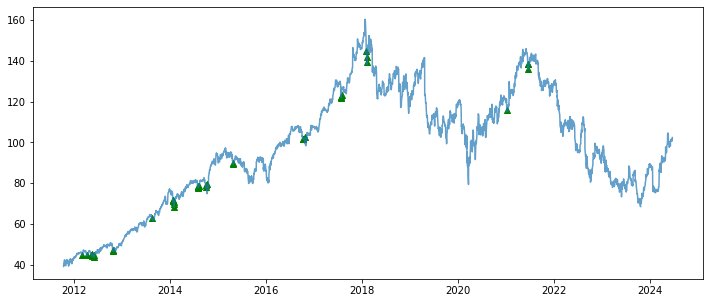

In [19]:
plt.figure(figsize=(12,5))
plt.scatter(frame.loc[buy].index,frame.loc[buy]['Adj Close'],marker='^',c='g')
plt.plot(frame['Adj Close'], alpha=0.7) 

In [20]:
Profits = (frame.loc[sell].Open.values-frame.loc[buy].Open.values)/frame.loc[buy].Open.values

In [21]:
Profits 

array([ 0.01841854,  0.01323806, -0.01151832, -0.01105804,  0.00212308,
        0.0128755 ,  0.03632402,  0.02847873,  0.01033364,  0.0155809 ,
        0.01012237, -0.00346098,  0.00108167, -0.00407381,  0.0234597 ,
        0.01052877,  0.02759933,  0.00556548,  0.00556548,  0.01286476,
        0.00628347,  0.01170137,  0.01861873,  0.01306249,  0.02097651,
        0.01300845,  0.01320229, -0.00076646,  0.00355307, -0.01841874,
        0.01366924,  0.02033738,  0.01195275,  0.01594998,  0.00852708,
        0.02154841,  0.00861575,  0.01892713, -0.00528457,  0.01409034,
        0.01120923])

In [22]:
wins = [i for i in Profits if i>0]

In [23]:
len(wins)/len(Profits) 

0.8292682926829268

In [24]:
len(Profits) 

41

For one asset, it is possible to make only 41 trades from the starting date till now, which is not that much. So, we have to consider multiple assets

#### Evaluating the strategy on all the 500 stocks

In [29]:
tickers.pop(213)  

'GEV'

In [32]:
tickers.pop(419) 

'SOLV'

In [34]:
tickers.pop(466) 

'VLTO'

In [39]:
matrixsignals = []
matrixprofits = []

for i in range(len(tickers)):
    print(i, tickers[i]) 
    frame = RSIcalc(tickers[i]) 
    buy, sell = getSignals(frame)
    Profits = (frame.loc[sell].Open.values-frame.loc[buy].Open.values)/frame.loc[buy].Open.values
    matrixsignals.append(buy)
    matrixprofits.append(Profits) 

0 MMM


[*********************100%%**********************]  1 of 1 completed


1 AOS


[*********************100%%**********************]  1 of 1 completed


2 ABT


...

494 XYL
495 YUM



[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed

496 ZBRA
497 ZBH



[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed

498 ZTS


In [41]:
len(matrixprofits)  

499

In [42]:
allprofit = []

for i in matrixprofits:
    for element in i:
        allprofit.append(element) 

In [43]:
len(allprofit) 

20326

In [44]:
wins = [i for i in allprofit if i>0]

In [45]:
len(wins) 

14364

In [47]:
len(wins)/len(allprofit) 

0.7066810981009545

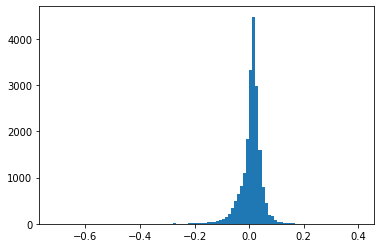

In [48]:
plt.hist(allprofit,bins=100)
plt.show() 